# H-013 · Banded rebalance / weak-signal flat

**Decides:** `REBALANCE_BAND_STAR` — REBALANCE_BAND_STAR / WEAK_SIGNAL_FLAT_Z_STAR

Sleeve: **core**. Primary metric: **net** `ann_sharpe`. `psr` = P(true SR > 0). STAR is manual.


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s3_fx_trend.report import (
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    require_star,
    save_star_stack,
    update_star_stack_key,
)
from backtest.s3_fx_trend.research import (
    RESEARCH_IS_END_S3,
    config_from_stack,
    register_hypothesis_arms,
    star_stack_path,
)
from backtest.s3_fx_trend.runner import run_s3_backtest
from backtest.s3_fx_trend.walkforward import embargo_bars_for_config, make_s3_folds
from data.ingestion.fx_fetcher import G10_V1_PAIRS
from data.processing.s3_fx_price_panel import price_panel_path, s3_data_dir
from strategies.s3_fx_trend.config import S3SimConfig

DATA_DIR = s3_data_dir(ROOT)
ARTIFACTS = os.path.join(ROOT, "04_backtest", "s3_fx_trend", "artifacts")
os.makedirs(ARTIFACTS, exist_ok=True)
TEARSHEET_DIR = ARTIFACTS
SLEEVE = "core"
HYP_ID = "H-013"
print("ROOT=", ROOT)
print("DATA_DIR=", DATA_DIR)
print("RESEARCH_IS_END_S3=", RESEARCH_IS_END_S3)


ROOT= c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
DATA_DIR= c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s3_fx_trend
RESEARCH_IS_END_S3= 2019-12-31 00:00:00


## 1. Load STAR stack


In [2]:
STACK_PATH = star_stack_path(SLEEVE)
stack = load_star_stack(STACK_PATH)
print("STAR stack path:", STACK_PATH)
print("Loaded keys with values:", {k: v for k, v in stack.items() if v is not None})
base_cfg = config_from_stack(stack)
print(base_cfg)


STAR stack path: C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s3_fx_trend\artifacts\s3_core_star_stack.json
Loaded keys with values: {'PAIR_VT_STAR': 'pair_vt', 'BOOK_VT_STAR': 'pair_plus_book_vt', 'CONVICTION_SCALING_STAR': 'sign_only', 'CARRY_MODE_STAR': 'tilt', 'VALUE_MODE_STAR': 'off', 'CARRY_AGREE_SCALE_STAR': '1.5', 'SPIKE_MODE_STAR': 'both', 'CORR_CONFLICT_MODE_STAR': 'off', 'HORIZON_STAR': '3M', 'FAMILY_STAR': 'tsmom'}
S3SimConfig(pairs=('EURUSD', 'USDJPY', 'GBPUSD', 'USDCHF', 'USDCAD', 'AUDUSD', 'NZDUSD'), bar='1d', day_boundary_tz='America/New_York', day_boundary_hour=17, signal_family='tsmom', tsmom_lookbacks=(21, 63, 252), tsmom_blend='single_3m', donchian_n=55, donchian_hl_source='daily_ny_close', pair_vt=True, book_vt=True, vt_target_ann_vol=0.1, conviction_scaling='sign', weak_signal_flat_z=0.0, rebalance_band=0.0, carry_mode='tilt', carry_refresh='weekly', value_mode='off', value_refresh='monthly', carry_agree_scale=1.5, carry_

## 2. Data load (research panels)


In [3]:
def _read_parquet(path: str) -> pd.DataFrame:
    if not os.path.isfile(path):
        warnings.warn(f"missing panel: {path}")
        return pd.DataFrame()
    df = pd.read_parquet(path)
    if df.empty:
        warnings.warn(f"empty panel: {path}")
        return df
    if "date" in df.columns:
        df = df.copy()
        df["date"] = pd.to_datetime(df["date"])
    return df

price_path = price_panel_path("1d", data_dir=DATA_DIR)
panel = _read_parquet(price_path)
rates = _read_parquet(os.path.join(DATA_DIR, "g10_policy_rates.parquet"))
reer = _read_parquet(os.path.join(DATA_DIR, "bis_reer_monthly.parquet"))

if not panel.empty:
    is_mask = panel["date"] <= pd.Timestamp(RESEARCH_IS_END_S3)
    panel_is = panel.loc[is_mask].copy()
    panel_oos = panel.loc[~is_mask].copy()
else:
    panel_is = panel.copy()
    panel_oos = panel.copy()

print("price rows:", len(panel), "IS:", len(panel_is), "OOS:", len(panel_oos))
print("rates rows:", len(rates), "reer rows:", len(reer))

s1_weekly = None
s2_daily = None
for cand in (
    os.path.join(ROOT, "01_data", "data_files", "s1_equities", "s1_period_returns.parquet"),
    os.path.join(ROOT, "04_backtest", "s1_equities", "artifacts", "s1_period_returns.parquet"),
):
    if os.path.isfile(cand):
        s1 = pd.read_parquet(cand)
        # best-effort: first numeric column as weekly series
        if "date" in s1.columns:
            s1 = s1.set_index(pd.to_datetime(s1["date"]))
        num = s1.select_dtypes(include=[np.number])
        if not num.empty:
            s1_weekly = num.iloc[:, 0]
        break


price rows: 39337 IS: 27096 OOS: 12241
rates rows: 7207 reer rows: 235


## 3. Arms (pre-register)


In [4]:
configs = {
    "off": config_from_stack(stack, hyp_overrides={"rebalance_band": 0.0, "weak_signal_flat_z": 0.0}),
    "band_10": config_from_stack(stack, hyp_overrides={"rebalance_band": 0.10}),
    "band_20": config_from_stack(stack, hyp_overrides={"rebalance_band": 0.20}),
    "weak_flat": config_from_stack(stack, hyp_overrides={"weak_signal_flat_z": 0.25}),
}
register_hypothesis_arms(HYP_ID, list(configs.keys()), sleeve=SLEEVE, overwrite=True)
print("registered", list(configs.keys()))


registered ['off', 'band_10', 'band_20', 'weak_flat']


## 4. Fold-val + boxplots

Boxplots use **net** Sharpe and max DD (shown inline). Full-IS is computed here; the locked metrics table is shown in §5.


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,2007-01-01,2009-10-30,989,2009-10-31,2009-11-04,2009-11-05,2012-08-12,994
1,2,2007-01-01,2012-08-06,1983,2012-08-07,2012-08-12,2012-08-13,2016-04-14,994
2,3,2007-01-01,2016-04-07,2977,2016-04-10,2016-04-14,2016-04-17,2019-12-30,995


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,arm,fold_id,ann_sharpe,ann_sharpe_gross,max_drawdown,calmar,corr_to_s1,corr_to_s2,psr,dsr_local,dsr_stack,skew,excess_kurtosis,cost_bps_per_year,n_days,n_entries,n_trials_local,n_trials_stack
0,off,1,0.667028,0.733945,-0.119614,0.466034,NaN,NaN,1.000000,1.000000,1.000000,0.048954,0.302889,198.500508,992,330,4,40
1,off,2,0.151420,0.312800,-0.139253,0.068751,0.228458,NaN,0.999999,0.999887,0.994759,-0.025750,-0.257739,266.315856,992,373,4,40
2,off,3,0.106646,0.198635,-0.095557,0.057809,-0.020511,NaN,0.999601,0.989369,0.878529,0.015347,-0.353283,318.792651,993,427,4,40
3,band_10,1,0.620698,0.684309,-0.122370,0.422874,NaN,NaN,1.000000,1.000000,1.000000,0.053475,0.304529,198.316804,992,330,4,40
4,band_10,2,0.088394,0.245573,-0.149727,0.026166,0.233945,NaN,0.997233,0.957759,0.722864,-0.031288,-0.273561,266.177110,992,373,4,40
5,band_10,3,0.098858,0.185277,-0.104832,0.046201,-0.018753,NaN,0.999063,0.980247,0.821991,0.015724,-0.315091,318.038677,993,427,4,40
6,band_20,1,0.568209,0.631692,-0.121480,0.385998,NaN,NaN,1.000000,1.000000,1.000000,0.018525,0.308589,198.260269,992,330,4,40
7,band_20,2,0.184472,0.340920,-0.136496,0.091675,0.237975,NaN,1.000000,0.999999,0.999830,-0.029872,-0.299297,266.066179,992,373,4,40
8,band_20,3,0.115855,0.204309,-0.104857,0.060423,-0.025336,NaN,0.999865,0.995230,0.927417,0.016171,-0.342935,318.262095,993,427,4,40
9,weak_flat,1,-0.571920,-0.504016,-0.000398,-0.254070,NaN,NaN,0.010803,0.007519,0.004989,-30.600001,950.932254,0.359843,992,1,4,40


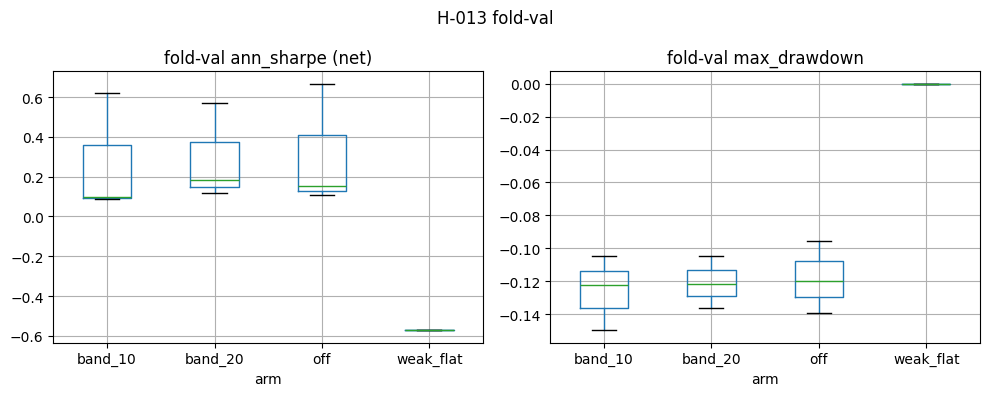

median_sharpe_hint (commentary only): band_20


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [5]:
FULL_IS_COLS = [
    "arm",
    "ann_sharpe",
    "ann_sharpe_gross",
    "max_drawdown",
    "corr_to_s1",
    "corr_to_s2",
    "calmar",
    "psr",
    "dsr_local",
    "dsr_stack",
    "skew",
    "excess_kurtosis",
    "cost_bps_per_year",
    "n_days",
    "n_entries",
]

fold_df = pd.DataFrame()
full_is_df = pd.DataFrame()
_reer = reer if "reer" in dir() else pd.DataFrame()

if panel_is.empty or "date" not in panel_is.columns:
    print("SKIP fold-val / full-IS: research IS price panel missing or empty.")
    print("Run 01_data/data_files/s3_fx_trend/s3_research_panels.ipynb first.")
else:
    is_dates = pd.DatetimeIndex(panel_is["date"].drop_duplicates().sort_values())
    try:
        folds = make_s3_folds(
            is_dates,
            n_folds=3,
            embargo_bars=embargo_bars_for_config(bar=getattr(base_cfg, "bar", "1d")),
        )
        display(fold_table(folds))
        fold_df = fold_val_metrics(
            panel_is,
            folds,
            configs,
            hyp_id=HYP_ID,
            sleeve=SLEEVE,
            s1_weekly=s1_weekly,
            s2_daily=s2_daily,
            rates_df=rates if not rates.empty else None,
            reer_df=_reer if not _reer.empty else None,
        )
        display(fold_df.head(20))

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        if not fold_df.empty and "ann_sharpe" in fold_df.columns:
            fold_df.boxplot(column="ann_sharpe", by="arm", ax=axes[0])
            axes[0].set_title("fold-val ann_sharpe (net)")
            axes[0].set_xlabel("arm")
        if not fold_df.empty and "max_drawdown" in fold_df.columns:
            fold_df.boxplot(column="max_drawdown", by="arm", ax=axes[1])
            axes[1].set_title("fold-val max_drawdown")
            axes[1].set_xlabel("arm")
        plt.suptitle(f"{HYP_ID} fold-val")
        plt.tight_layout()
        plt.show()

        full_is_df = full_is_metrics(
            panel_is,
            configs,
            hyp_id=HYP_ID,
            sleeve=SLEEVE,
            s1_weekly=s1_weekly,
            s2_daily=s2_daily,
            rates_df=rates if not rates.empty else None,
            reer_df=_reer if not _reer.empty else None,
        )
        hint = median_sharpe_hint(fold_df)
        print("median_sharpe_hint (commentary only):", hint)
    except Exception as exc:
        warnings.warn(f"fold-val / full-IS failed (panel may be too short): {exc!r}")


## 5. Full-IS metrics table

Locked columns: `ann_sharpe`, `ann_sharpe_gross`, `max_drawdown`, `corr_to_s1`, `corr_to_s2`, `calmar`, `psr`, `dsr_local`, `dsr_stack`, `skew`, `excess_kurtosis`, `cost_bps_per_year`, `n_days`, `n_entries`.


In [6]:
display(full_is_df[[c for c in FULL_IS_COLS if c in full_is_df.columns]]) if not full_is_df.empty else print('no full-IS yet')


,arm,ann_sharpe,ann_sharpe_gross,max_drawdown,corr_to_s1,corr_to_s2,calmar,psr,dsr_local,dsr_stack,skew,excess_kurtosis,cost_bps_per_year,n_days,n_entries
0,off,0.494978,0.598272,-0.168226,0.028823,NaN,0.242711,1.000000,1.000000e+00,1.000000e+00,0.006560,-0.079265,230.608556,3975,1406
1,band_10,0.458272,0.557529,-0.173883,0.028552,NaN,0.215665,1.000000,1.000000e+00,1.000000e+00,-0.003015,-0.061275,230.288820,3975,1406
2,band_20,0.483301,0.583884,-0.164362,0.025243,NaN,0.241270,1.000000,1.000000e+00,1.000000e+00,-0.002922,-0.085954,230.336477,3975,1406
3,weak_flat,-0.292279,-0.284712,-0.011824,NaN,NaN,-0.059431,0.000001,3.875674e-07,8.471781e-08,-17.781052,921.964149,0.205405,3975,4


## 6. Freeze STAR (manual)


In [8]:
# MANUAL STAR freeze — edit the value, then run. Do not auto-assign from hint.
# STAR_KEY = "REBALANCE_BAND_STAR"
# STAR_VALUE = None  # e.g. "0.1"

STAR_KEY = "REBALANCE_BAND_STAR"
STAR_VALUE = "off"  # <-- set manually after reviewing fold-val / full-IS

if STAR_VALUE is None:
    print(f"STAR_VALUE is None — leave unset until you decide. stack[{STAR_KEY!r}] stays as-is.")
else:
    update_star_stack_key(STACK_PATH, STAR_KEY, STAR_VALUE)
    stack = load_star_stack(STACK_PATH)
    require_star(STAR_KEY, stack.get(STAR_KEY))
    print("Froze", STAR_KEY, "=", stack.get(STAR_KEY))


Froze REBALANCE_BAND_STAR = off
